# TOI-791 b and c: reproducible catalog, density, and PhotoRing analysis

This notebook repeats the TOI-2449 exercise for the two known planets in TOI-791. It discovers the current NASA Exoplanet Archive rows at runtime, preserves the raw catalog responses, downloads the available TESS SPOC light curves, and applies the same density and photoeccentric diagnostics to each planet.

The notebook deliberately does not hard-code literature values: catalog solutions and identifiers can change. Results derived from one-dimensional catalog summaries are diagnostic only; a formal claim requires joint posterior samples and an independent stellar-density posterior.

In [1]:
from pathlib import Path
from io import BytesIO
import json
import re
import sys
import urllib.parse
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, R_sun

ROOT = Path.cwd()
if not (ROOT / 'pipeline' / 'exorings').is_dir():
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pipeline' / 'exorings').is_dir()), ROOT)
DATA = Path.cwd() / 'data' / 'toi791'
FIGURES = Path.cwd() / 'figures'
DATA.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')
SYSTEM = 'TOI-791'
PLANETS = ['TOI-791 b', 'TOI-791 c']
ROOT, DATA, FIGURES

(PosixPath('/Users/jzuluaga/dev/PRisma'),
 PosixPath('/Users/jzuluaga/dev/PRisma/papers/TOI-791/data/toi791'),
 PosixPath('/Users/jzuluaga/dev/PRisma/papers/TOI-791/figures'))

## 1. Catalog records and identifiers

All columns returned by NASA are retained. The composite table is used for the working comparison, while the full `ps` table preserves alternative published solutions. TIC and Gaia identifiers are extracted from the host row when available.

In [2]:
def read_url(url, params=None, timeout=120):
    if params:
        url = f'{url}?{urllib.parse.urlencode(params)}'
    with urllib.request.urlopen(url, timeout=timeout) as response:
        payload = response.read()
    return payload


def nasa_tap(table, where):
    payload = read_url('https://exoplanetarchive.ipac.caltech.edu/TAP/sync', {'query': f'select * from {table} where {where}', 'format': 'csv'})
    (DATA / f'nasa_{table}.csv').write_bytes(payload)
    return pd.read_csv(BytesIO(payload))


ps = nasa_tap('ps', "hostname='TOI-791'")
pscomppars = nasa_tap('pscomppars', "hostname='TOI-791'")
stellarhosts = nasa_tap('stellarhosts', "hostname='TOI-791'")
if pscomppars.empty:
    raise RuntimeError('NASA Exoplanet Archive returned no TOI-791 composite rows.')

planet_rows = pscomppars[pscomppars['pl_name'].isin(PLANETS)].copy()
if len(planet_rows) != 2:
    PLANETS = sorted(pscomppars.loc[pscomppars['pl_name'].str.startswith('TOI-791 '), 'pl_name'].unique())
    planet_rows = pscomppars[pscomppars['pl_name'].isin(PLANETS)].copy()
print('Planets found:', PLANETS)
identifier_columns = ['tic_id', 'gaia_dr3_id', 'gaia_dr2_id', 'sy_ticid', 'gaia_id']
parameter_columns = ['pl_orbper', 'pl_tranmid', 'pl_ratror', 'pl_imppar', 'pl_orbincl', 'pl_orbeccen', 'pl_orblper', 'pl_ratdor', 'st_mass', 'st_rad', 'st_dens']
display_columns = ['pl_name', 'hostname'] + [c for c in identifier_columns + parameter_columns if c in planet_rows]
display(planet_rows[display_columns])

Planets found: ['TOI-791 b', 'TOI-791 c']


,pl_name,hostname,tic_id,gaia_dr3_id,gaia_dr2_id,pl_orbper,pl_tranmid,pl_ratror,pl_imppar,pl_orbincl,pl_orbeccen,pl_orblper,pl_ratdor,st_mass,st_rad,st_dens
0,TOI-791 b,TOI-791,TIC 306472057,Gaia DR3 5270467966514084224,Gaia DR2 5270467966514084224,139.29931,2.459263e+06,0.06924,0.313,89.797,0.032,NaN,NaN,1.28,1.474,0.689992
1,TOI-791 c,TOI-791,TIC 306472057,Gaia DR3 5270467966514084224,Gaia DR2 5270467966514084224,232.01570,2.459434e+06,0.08050,0.671,89.695,0.028,NaN,NaN,1.28,1.474,0.689992


In [3]:
def first_value(frame, names):
    for name in names:
        if name in frame and frame[name].notna().any():
            return frame[name].dropna().iloc[0]
    return None


def numeric_identifier(value):
    if value is None or pd.isna(value):
        return None
    tokens = re.findall(r'\d+', str(value))
    return int(tokens[-1]) if tokens else None


tic_value = first_value(stellarhosts, ['tic_id', 'sy_ticid']) or first_value(planet_rows, ['tic_id', 'sy_ticid'])
gaia_value = first_value(stellarhosts, ['gaia_dr3_id', 'gaia_id', 'gaia_dr2_id']) or first_value(planet_rows, ['gaia_dr3_id', 'gaia_id', 'gaia_dr2_id'])
tic_id = numeric_identifier(tic_value)
gaia_id = numeric_identifier(gaia_value)

if gaia_id is not None:
    query = f'SELECT * FROM gaiadr3.gaia_source WHERE source_id={gaia_id}'
    gaia_raw = read_url('https://gea.esac.esa.int/tap-server/tap/sync', {'REQUEST': 'doQuery', 'LANG': 'ADQL', 'FORMAT': 'csv', 'QUERY': query})
    (DATA / 'gaia_dr3_source.csv').write_bytes(gaia_raw)
    gaia = pd.read_csv(BytesIO(gaia_raw))
else:
    gaia = pd.DataFrame()

if tic_id is not None:
    mast_request = {'service': 'Mast.Catalogs.Filtered.Tic.Rows', 'params': {'columns': '*', 'filters': [{'paramName': 'ID', 'values': [str(tic_id)]}]}, 'format': 'json', 'pagesize': 100, 'page': 1}
    body = urllib.parse.urlencode({'request': json.dumps(mast_request)}).encode()
    request = urllib.request.Request('https://mast.stsci.edu/api/v0/invoke', data=body)
    with urllib.request.urlopen(request, timeout=120) as response:
        tic_payload = response.read()
    (DATA / 'tic_v8.json').write_bytes(tic_payload)
    tic = pd.DataFrame(json.loads(tic_payload).get('data', []))
    tic.to_csv(DATA / 'tic_v8.csv', index=False)
else:
    tic = pd.DataFrame()
print({'TIC': tic_id, 'Gaia DR3': gaia_id, 'Gaia rows': len(gaia), 'TIC rows': len(tic)})

{'TIC': 306472057, 'Gaia DR3': 5270467966514084224, 'Gaia rows': 1, 'TIC rows': 1}


## 1.1. Adopted stellar and planetary properties

The table below exposes the composite NASA values used by the subsequent diagnostics. Uncertainties are retained in the downloaded `pscomppars` file; the displayed table is a compact working summary.

In [4]:
stellar_fields = {
    'ra_deg': ('ra', 'deg'),
    'dec_deg': ('dec', 'deg'),
    'effective_temperature': ('st_teff', 'K'),
    'stellar_mass': ('st_mass', 'M_sun'),
    'stellar_radius': ('st_rad', 'R_sun'),
    'surface_gravity': ('st_logg', 'dex cgs'),
    'metallicity': ('st_met', 'dex'),
    'catalog_density': ('st_dens', 'g cm^-3'),
}
reference_row = planet_rows.iloc[0]
stellar_properties = pd.DataFrame(
    [
        {'parameter': label, 'value': reference_row.get(column, np.nan), 'unit': unit}
        for label, (column, unit) in stellar_fields.items()
    ]
).set_index('parameter')
stellar_properties.to_csv(DATA / 'stellar_properties.csv')

planet_fields = {
    'period_day': 'pl_orbper',
    'transit_epoch_bjd': 'pl_tranmid',
    'radius_ratio': 'pl_ratror',
    'impact_parameter': 'pl_imppar',
    'inclination_deg': 'pl_orbincl',
    'duration_hour': 'pl_trandur',
    'radius_earth': 'pl_rade',
    'mass_earth': 'pl_bmasse',
    'eccentricity': 'pl_orbeccen',
    'omega_deg': 'pl_orblper',
}
planet_properties = planet_rows.set_index('pl_name')[[column for column in planet_fields.values() if column in planet_rows]].rename(columns={value: key for key, value in planet_fields.items()})
planet_properties.to_csv(DATA / 'planet_properties.csv')

print('Stellar properties adopted from NASA pscomppars')
display(stellar_properties)
print('Planet and transit properties adopted from NASA pscomppars')
display(planet_properties)

Stellar properties adopted from NASA pscomppars


,value,unit
parameter,,
ra_deg,118.434757,deg
dec_deg,-69.701736,deg
effective_temperature,6294.000000,K
stellar_mass,1.280000,M_sun
stellar_radius,1.474000,R_sun
surface_gravity,3.710000,dex cgs
metallicity,-0.140000,dex
catalog_density,0.689992,g cm^-3


Planet and transit properties adopted from NASA pscomppars


,period_day,transit_epoch_bjd,radius_ratio,impact_parameter,inclination_deg,duration_hour,radius_earth,mass_earth,eccentricity,omega_deg
pl_name,,,,,,,,,,
TOI-791 b,139.29931,2.459263e+06,0.06924,0.313,89.797,12.366,11.130518,9.5,0.032,NaN
TOI-791 c,232.01570,2.459434e+06,0.08050,0.671,89.695,11.926,12.946373,18.6,0.028,NaN


## 2. TESS light curves

The MAST search is performed on the host TIC and keeps every available SPOC/TESS-SPOC product. Transit windows are plotted separately for b and c when a catalog transit epoch is available.

In [5]:
cached_light_curves = sorted(DATA.glob('tess_sector*_exposure*s.csv'))
if cached_light_curves:
    print(f'Using {len(cached_light_curves)} cached TESS light curves from {DATA}; no download performed.')
else:
    try:
        import lightkurve as lk
    except ImportError:
        %pip install -q lightkurve
        import lightkurve as lk

    if tic_id is None:
        raise RuntimeError('No TIC identifier was returned for TOI-791.')
    search_all = lk.search_lightcurve(f'TIC {int(float(tic_id))}', mission='TESS')
    if len(search_all) == 0:
        raise RuntimeError('MAST returned no TESS light-curve products for the host TIC.')
    if 'author' in search_all.table.colnames:
        authors = np.asarray(search_all.table['author']).astype(str)
        search = search_all[np.isin(authors, ['SPOC', 'TESS-SPOC'])]
    else:
        print('MAST response has no author column; retaining all returned products.')
        search = search_all
    display(search.table)
    collection = search.download_all(quality_bitmask='default', download_dir=str(DATA / 'mast_cache'))
    for light_curve in collection:
        sector = int(light_curve.meta.get('SECTOR', -1))
        exposure = float(light_curve.meta.get('EXPOSURE', np.nan))
        light_curve.remove_nans().to_pandas().to_csv(DATA / f'tess_sector{sector}_exposure{exposure:g}s.csv')
    cached_light_curves = sorted(DATA.glob('tess_sector*_exposure*s.csv'))
    print(f'{len(cached_light_curves)} light curves downloaded')

Using 74 cached TESS light curves from /Users/jzuluaga/dev/PRisma/papers/TOI-791/data/toi791; no download performed.


### Phase-folded transit light curves

Every downloaded PDCSAP curve is normalized independently and folded on the catalog ephemeris. The small markers are individual measurements; the black points are inverse-variance-unweighted 15-minute bins. This visualization is a data check, not a refit.

Saved: /Users/jzuluaga/dev/PRisma/papers/TOI-791/figures/tess_phase_folded_transits.png


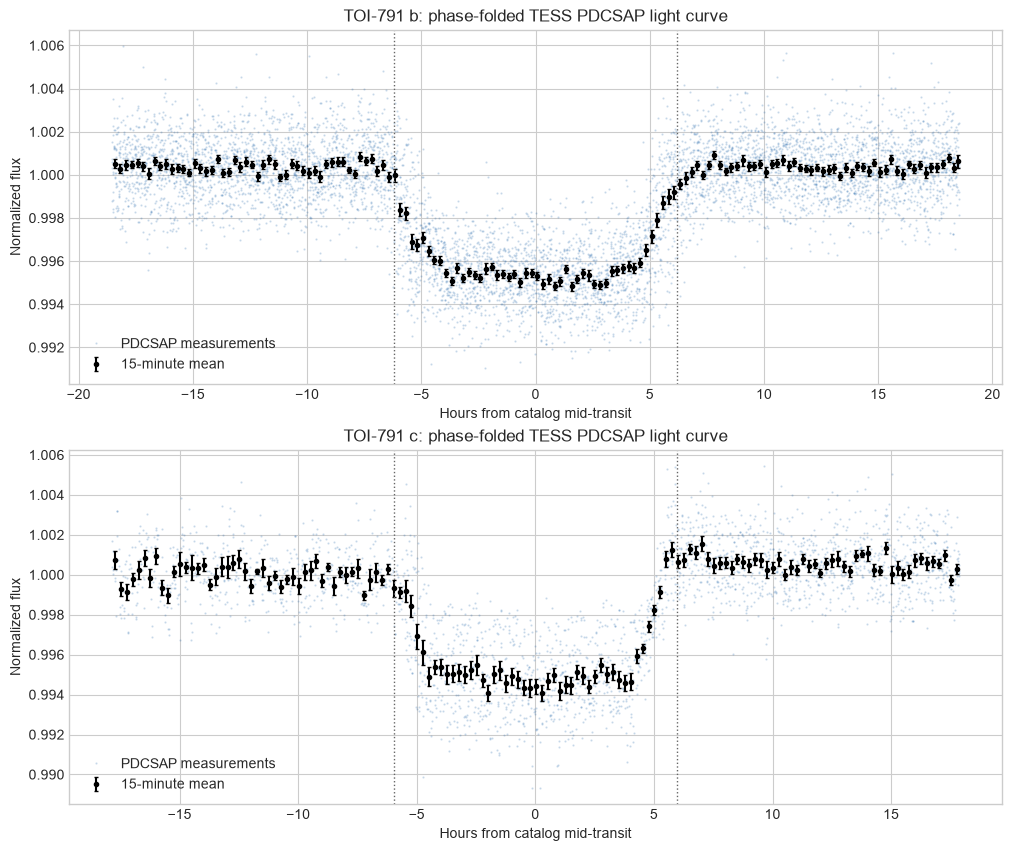

In [6]:
light_curve_paths = sorted(DATA.glob('tess_sector*_exposure*s.csv'))
if not light_curve_paths:
    raise FileNotFoundError('No exported TESS CSV files found. Run the previous cell first.')

required_transit_columns = ['pl_name', 'pl_orbper', 'pl_tranmid', 'pl_trandur']
missing_transit_columns = [column for column in required_transit_columns if column not in planet_rows]
if missing_transit_columns:
    raise KeyError(f'NASA catalog rows are missing: {missing_transit_columns}')
transit_parameters = (
    planet_rows[required_transit_columns]
    .rename(columns={'pl_name': 'planet', 'pl_orbper': 'period_day', 'pl_tranmid': 't0_bjd', 'pl_trandur': 'duration_hour'})
    .set_index('planet')
)


def folded_transit_points(period_day, epoch_bjd, duration_hour):
    windows = []
    half_window_hour = max(1.5 * duration_hour, 4.0)
    for path in light_curve_paths:
        frame = pd.read_csv(path)
        required = {'time', 'flux', 'flux_err'}
        if not required.issubset(frame.columns):
            continue
        valid = np.isfinite(frame['time']) & np.isfinite(frame['flux']) & np.isfinite(frame['flux_err']) & (frame['flux_err'] > 0)
        frame = frame.loc[valid, ['time', 'flux', 'flux_err']].copy()
        if frame.empty:
            continue
        median_flux = frame['flux'].median()
        frame['relative_flux'] = frame['flux'] / median_flux
        frame['relative_flux_err'] = frame['flux_err'] / median_flux
        bjd = frame['time'].to_numpy() + 2457000.0
        frame['phase_hour'] = ((bjd - epoch_bjd + period_day / 2) % period_day - period_day / 2) * 24
        windows.append(frame[np.abs(frame['phase_hour']) <= half_window_hour])
    return pd.concat(windows, ignore_index=True) if windows else pd.DataFrame()


fig, axes = plt.subplots(len(transit_parameters), 1, figsize=(10, 4.2 * len(transit_parameters)), sharex=False, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (planet, row) in zip(axes, transit_parameters.iterrows()):
    points = folded_transit_points(row['period_day'], row['t0_bjd'], row['duration_hour'])
    if points.empty:
        ax.text(.5, .5, 'No valid points in transit windows', transform=ax.transAxes, ha='center')
        continue
    ax.plot(points['phase_hour'], points['relative_flux'], '.', ms=1.2, color='#2166AC', alpha=.20, label='PDCSAP measurements')
    bin_edges = np.arange(points['phase_hour'].min(), points['phase_hour'].max() + .25, .25)
    points['bin'] = pd.cut(points['phase_hour'], bin_edges)
    binned = points.groupby('bin', observed=True).agg(phase_hour=('phase_hour', 'mean'), relative_flux=('relative_flux', 'mean'), relative_flux_err=('relative_flux', lambda value: value.std() / np.sqrt(len(value)))).dropna()
    ax.errorbar(binned['phase_hour'], binned['relative_flux'], yerr=binned['relative_flux_err'], fmt='o', ms=3, color='black', capsize=1.5, label='15-minute mean')
    ax.axvline(-row['duration_hour'] / 2, color='0.4', ls=':', lw=1)
    ax.axvline(row['duration_hour'] / 2, color='0.4', ls=':', lw=1)
    ax.set(title=f'{planet}: phase-folded TESS PDCSAP light curve', xlabel='Hours from catalog mid-transit', ylabel='Normalized flux')
    ax.legend(loc='best')

transit_figure = FIGURES / 'tess_phase_folded_transits.png'
fig.savefig(transit_figure, dpi=300, bbox_inches='tight')
print('Saved:', transit_figure)

## 3. Stellar and transit-density diagnostics

For each planet, the independent density is $\rho_\star=(M_\star/M_\odot)/(R_\star/R_\odot)^3\rho_\odot$. The circular transit density uses `a/R*` when published; otherwise it is reconstructed from period, duration, impact parameter, and radius ratio when those fields exist. The calculation is intentionally labeled approximate because catalog summaries are not a joint posterior.

In [16]:
rho_sun_si = (M_sun / (4 * np.pi * R_sun**3 / 3)).to_value('kg/m3')
G_SI = G.value


def number(row, name):
    value = row.get(name, np.nan)
    return float(value) if pd.notna(value) else np.nan


def circular_density(row):
    period = number(row, 'pl_orbper')
    a_over_r = number(row, 'pl_ratdor')
    if np.isfinite(period) and np.isfinite(a_over_r):
        return 3 * np.pi / (G_SI * (period * 86400)**2) * a_over_r**3

    duration_hour = number(row, 'pl_trandur')
    impact = number(row, 'pl_imppar')
    radius_ratio = number(row, 'pl_ratror')
    if not all(np.isfinite(value) for value in [period, duration_hour, impact, radius_ratio]):
        return np.nan
    phase = np.pi * (duration_hour / 24) / period
    if not 0 < phase < np.pi / 2 or impact < 0 or radius_ratio <= 0:
        return np.nan
    a_over_r = np.sqrt(impact**2 + ((1 + radius_ratio)**2 - impact**2) / np.sin(phase)**2)
    return 3 * np.pi / (G_SI * (period * 86400)**2) * a_over_r**3


diagnostics = []
for _, row in planet_rows.iterrows():
    mass = number(row, 'st_mass')
    radius = number(row, 'st_rad')
    rho_true = rho_sun_si * mass / radius**3 if mass > 0 and radius > 0 else number(row, 'st_dens') * 1000
    rho_observed = circular_density(row)
    diagnostics.append({
        'planet': row['pl_name'],
        'rho_true_kg_m3': rho_true,
        'rho_observed_circular_kg_m3': rho_observed,
        'rho_observed_over_true': rho_observed / rho_true if rho_true > 0 else np.nan,
        'period_day': number(row, 'pl_orbper'),
        't0_bjd': number(row, 'pl_tranmid'),
        'duration_hour': number(row, 'pl_trandur'),
        'p': number(row, 'pl_ratror'),
        'b': number(row, 'pl_imppar'),
        'inclination_deg': number(row, 'pl_orbincl'),
        'a_over_r_catalog': number(row, 'pl_ratdor'),
        'e': number(row, 'pl_orbeccen'),
        'omega_deg': number(row, 'pl_orblper'),
    })

diagnostics = pd.DataFrame(diagnostics).set_index('planet')
diagnostics.to_csv(DATA / 'density_diagnostics.csv')
display(diagnostics[['rho_true_kg_m3', 'rho_observed_circular_kg_m3', 'rho_observed_over_true', 'period_day', 'duration_hour', 'p', 'b', 'inclination_deg']])

,rho_true_kg_m3,rho_observed_circular_kg_m3,rho_observed_over_true,period_day,duration_hour,p,b,inclination_deg
planet,,,,,,,,
TOI-791 b,563.46742,664.026609,1.178465,139.29931,12.366,0.06924,0.313,89.797
TOI-791 c,563.46742,700.776290,1.243686,232.01570,11.926,0.08050,0.671,89.695


### Complete planet and transit-property table

This working table combines the NASA composite values with the derived circular-transit density. It is the compact reference for both planets used by the phase-folded, photoeccentric, and PhotoRing diagnostics.

In [17]:
complete_property_columns = {
    'mass_earth': 'pl_bmasse',
    'mass_jupiter': 'pl_bmassj',
    'radius_earth': 'pl_rade',
    'radius_jupiter': 'pl_radj',
    'semi_major_axis_au': 'pl_orbsmax',
    'period_day': 'pl_orbper',
    'transit_epoch_bjd': 'pl_tranmid',
    'transit_depth_ppm': 'pl_trandep',
    'radius_ratio': 'pl_ratror',
    'impact_parameter': 'pl_imppar',
    'inclination_deg': 'pl_orbincl',
    'duration_hour': 'pl_trandur',
    'a_over_r_catalog': 'pl_ratdor',
    'eccentricity': 'pl_orbeccen',
    'eccentricity_err_plus': 'pl_orbeccenerr1',
    'eccentricity_err_minus': 'pl_orbeccenerr2',
    'omega_deg': 'pl_orblper',
    'omega_err_plus_deg': 'pl_orblpererr1',
    'omega_err_minus_deg': 'pl_orblpererr2',
}
complete_properties = planet_rows.set_index('pl_name')[[column for column in complete_property_columns.values() if column in planet_rows]].rename(columns={value: key for key, value in complete_property_columns.items()})
for column in ['eccentricity_err_minus', 'omega_err_minus_deg']:
    if column in complete_properties:
        complete_properties[column] = complete_properties[column].abs()
complete_properties = complete_properties.join(diagnostics[['rho_true_kg_m3', 'rho_observed_circular_kg_m3', 'rho_observed_over_true']])
complete_properties.to_csv(DATA / 'complete_planet_and_transit_properties.csv')
display(complete_properties)

,mass_earth,mass_jupiter,radius_earth,radius_jupiter,semi_major_axis_au,period_day,transit_epoch_bjd,transit_depth_ppm,radius_ratio,impact_parameter,inclination_deg,duration_hour,a_over_r_catalog,eccentricity,eccentricity_err_plus,eccentricity_err_minus,omega_deg,omega_err_plus_deg,omega_err_minus_deg,rho_true_kg_m3,rho_observed_circular_kg_m3,rho_observed_over_true
pl_name,,,,,,,,,,,,,,,,,,,,,,
TOI-791 b,9.5,0.029890,11.130518,0.993,0.602,139.29931,2.459263e+06,0.5428,0.06924,0.313,89.797,12.366,NaN,0.032,0.014,0.032,NaN,NaN,NaN,563.46742,664.026609,1.178465
TOI-791 c,18.6,0.058522,12.946373,1.155,0.863,232.01570,2.459434e+06,0.6780,0.08050,0.671,89.695,11.926,NaN,0.028,0.013,0.028,NaN,NaN,NaN,563.46742,700.776290,1.243686


In [18]:
def psi_photoeccentric(e, omega_deg):
    omega = np.deg2rad(omega_deg)
    return (1 + e * np.sin(omega))**3 / (1 - e**2)**1.5


def emin_from_psi(psi):
    q = np.power(np.asarray(psi, dtype=float), 2 / 3)
    return np.abs((q - 1) / (q + 1))


published_orbits = planet_rows.set_index('pl_name')
pe_rows = []
for planet, row in diagnostics.iterrows():
    catalog_row = published_orbits.loc[planet]
    psi = row['rho_observed_over_true']
    e = row['e']
    omega = row['omega_deg']
    pe_rows.append({
        'planet': planet,
        'Psi_observed': psi,
        'e_min_required': emin_from_psi(psi) if psi > 0 else np.nan,
        'Psi_from_catalog_e_omega': psi_photoeccentric(e, omega) if 0 <= e < 1 and np.isfinite(omega) else np.nan,
        'e_catalog': e,
        'e_err_plus': number(catalog_row, 'pl_orbeccenerr1'),
        'e_err_minus': abs(number(catalog_row, 'pl_orbeccenerr2')),
        'omega_deg_catalog': omega,
    })
pe_summary = pd.DataFrame(pe_rows).set_index('planet')
pe_summary.to_csv(DATA / 'photoeccentric_summary.csv')
display(pe_summary)
print('The catalog reports asymmetric eccentricity errors but no omega value; a catalog Psi(e, omega) prediction is therefore unavailable.')

,Psi_observed,e_min_required,Psi_from_catalog_e_omega,e_catalog,e_err_plus,e_err_minus,omega_deg_catalog
planet,,,,,,,
TOI-791 b,1.178465,0.054683,NaN,0.032,0.014,0.032,NaN
TOI-791 c,1.243686,0.072565,NaN,0.028,0.013,0.028,NaN


The catalog reports asymmetric eccentricity errors but no omega value; a catalog Psi(e, omega) prediction is therefore unavailable.


### Photoeccentric-effect diagnostic

For each planet, $\Psi_{\rm obs}=\rho_{\star,\rm obs,circ}/\rho_{\star,\rm true}$ is compared with the minimum eccentricity capable of producing it. A prediction from the catalog orbital solution requires both $e$ and $\omega$; the figure explicitly marks that prediction as unavailable if the Archive does not report $\omega$.

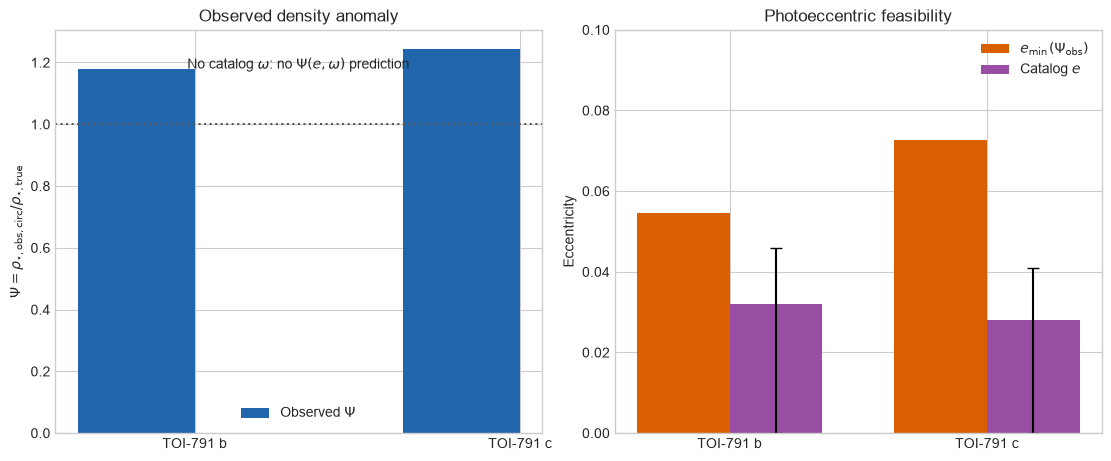

Saved: /Users/jzuluaga/dev/PRisma/papers/TOI-791/figures/photoeccentric_diagnostic.png


In [19]:
planet_labels = pe_summary.index.to_list()
positions = np.arange(len(planet_labels))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

axes[0].bar(positions - .18, pe_summary['Psi_observed'], width=.36, color='#2166AC', label=r'Observed $\Psi$')
predicted = pe_summary['Psi_from_catalog_e_omega']
if predicted.notna().any():
    axes[0].bar(positions + .18, predicted, width=.36, color='#4DAF4A', label=r'Catalog $\Psi(e,\omega)$')
else:
    axes[0].text(.5, .93, r'No catalog $\omega$: no $\Psi(e,\omega)$ prediction', transform=axes[0].transAxes, ha='center', va='top')
axes[0].axhline(1, color='0.35', ls=':', lw=1.5)
axes[0].set(xticks=positions, xticklabels=planet_labels, ylabel=r'$\Psi=\rho_{\star,\rm obs,circ}/\rho_{\star,\rm true}$', title='Observed density anomaly')
axes[0].legend(loc='best')

catalog_error = np.vstack([pe_summary['e_err_minus'].to_numpy(), pe_summary['e_err_plus'].to_numpy()])
axes[1].bar(positions - .18, pe_summary['e_min_required'], width=.36, color='#D95F02', label=r'$e_{\min}(\Psi_{\rm obs})$')
if pe_summary['e_catalog'].notna().any():
    axes[1].bar(positions + .18, pe_summary['e_catalog'], width=.36, yerr=catalog_error, capsize=4, color='#984EA3', label=r'Catalog $e$')
axes[1].set(xticks=positions, xticklabels=planet_labels, ylabel='Eccentricity', ylim=(0, max(.1, 1.2 * np.nanmax(np.r_[pe_summary['e_min_required'].to_numpy(), (pe_summary['e_catalog'] + pe_summary['e_err_plus']).to_numpy()]))), title='Photoeccentric feasibility')
axes[1].legend(loc='best')

photoeccentric_figure = FIGURES / 'photoeccentric_diagnostic.png'
fig.savefig(photoeccentric_figure, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', photoeccentric_figure)

### Minimum-eccentricity geometry

The left panel maps the photoeccentric density ratio for a reference $\omega=0^\circ$ and the orientations that maximize or minimize the effect. The right panel is the TOI-2449-style $e_{\min}(\Psi)$ curve: it gives the smallest eccentricity geometrically capable of producing each observed density ratio.

<>:14: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\P'
/var/folders/xn/75ncx53144919w099wx5x5mw0000gn/T/ipykernel_46728/3448400154.py:14: SyntaxWarning: invalid escape sequence '\P'
  axes[0].errorbar(row['e_catalog'], row['Psi_observed'], xerr=[[row['e_err_minus']], [row['e_err_plus']]], fmt='o', ms=7, capsize=3, label=f'{planet}: catalog $e$, observed $\Psi$')


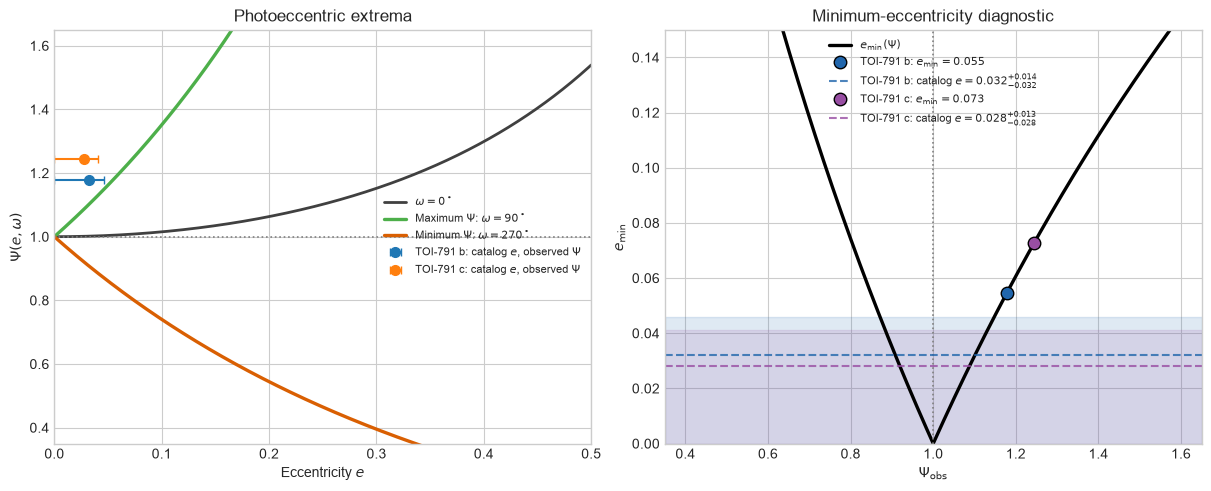

Saved: /Users/jzuluaga/dev/PRisma/papers/TOI-791/figures/photoeccentric_emin_geometry.png


In [20]:
e_grid = np.linspace(0, .5, 1000)
psi_omega_zero = psi_photoeccentric(e_grid, 0)
psi_maximum = psi_photoeccentric(e_grid, 90)
psi_minimum = psi_photoeccentric(e_grid, 270)
psi_grid = np.linspace(.35, 1.65, 1000)
emin_grid = emin_from_psi(psi_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].plot(e_grid, psi_omega_zero, color='0.25', lw=2, label=r'$\omega=0^\circ$')
axes[0].plot(e_grid, psi_maximum, color='#4DAF4A', lw=2.4, label=r'Maximum $\Psi$: $\omega=90^\circ$')
axes[0].plot(e_grid, psi_minimum, color='#D95F02', lw=2.4, label=r'Minimum $\Psi$: $\omega=270^\circ$')
for planet, row in pe_summary.iterrows():
    if np.isfinite(row['e_catalog']) and np.isfinite(row['Psi_observed']):
        axes[0].errorbar(row['e_catalog'], row['Psi_observed'], xerr=[[row['e_err_minus']], [row['e_err_plus']]], fmt='o', ms=7, capsize=3, label=f'{planet}: catalog $e$, observed $\Psi$')
axes[0].axhline(1, color='0.5', ls=':', lw=1.2)
axes[0].set(xlabel='Eccentricity $e$', ylabel=r'$\Psi(e,\omega)$', xlim=(0, .5), ylim=(.35, 1.65), title='Photoeccentric extrema')
axes[0].legend(fontsize=8, loc='best')

axes[1].plot(psi_grid, emin_grid, color='black', lw=2.4, label=r'$e_{\min}(\Psi)$')
axes[1].axvline(1, color='0.5', ls=':', lw=1.2)
for color, (planet, row) in zip(['#2166AC', '#984EA3'], pe_summary.iterrows()):
    if np.isfinite(row['Psi_observed']) and np.isfinite(row['e_min_required']):
        axes[1].plot(row['Psi_observed'], row['e_min_required'], 'o', ms=9, color=color, markeredgecolor='black', label=rf'{planet}: $e_{{\min}}={row["e_min_required"]:.3f}$')
    if np.isfinite(row['e_catalog']):
        lower = max(0, row['e_catalog'] - row['e_err_minus'])
        upper = row['e_catalog'] + row['e_err_plus']
        axes[1].axhspan(lower, upper, color=color, alpha=.14)
        axes[1].axhline(row['e_catalog'], color=color, ls='--', lw=1.5, alpha=.8, label=rf'{planet}: catalog $e={row["e_catalog"]:.3f}^{{+{row["e_err_plus"]:.3f}}}_{{-{row["e_err_minus"]:.3f}}}$')
axes[1].set(xlabel=r'$\Psi_{\rm obs}$', ylabel=r'$e_{\min}$', xlim=(.35, 1.65), ylim=(0, max(.15, 1.3 * np.nanmax(pe_summary['e_min_required']))), title='Minimum-eccentricity diagnostic')
axes[1].legend(fontsize=8, loc='best')

emin_figure = FIGURES / 'photoeccentric_emin_geometry.png'
fig.savefig(emin_figure, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', emin_figure)

## 4. PhotoRing maps

The following diagnostic uses the same Saturn-like reference ring as the TOI-2449 notebook ($f_i=1.526$, $f_e=2.269$, $\tau=1$). It is generated independently for b and c only when `rho_ind`, period, radius ratio, and impact parameter are finite. A map is not a ring fit: it shows the range of apparent density ratios produced by one illustrative ring model.

/Users/jzuluaga/dev/PRisma/pipeline/exorings/forward.py:159: RuntimeWarning: invalid value encountered in scalar power
  bobs = (((1 - pobs)**2 - (sfF / sfT) * (1 + pobs)**2) / (1 - sfF / sfT))**0.5


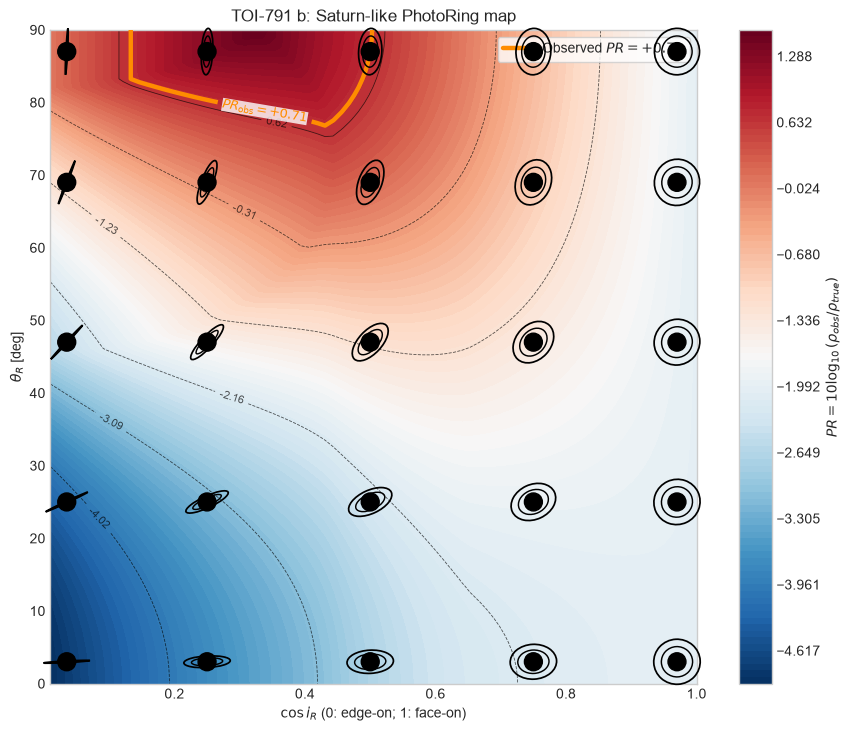

TOI-791 b: observed PR = +0.713; model range = [-4.945, +1.551]


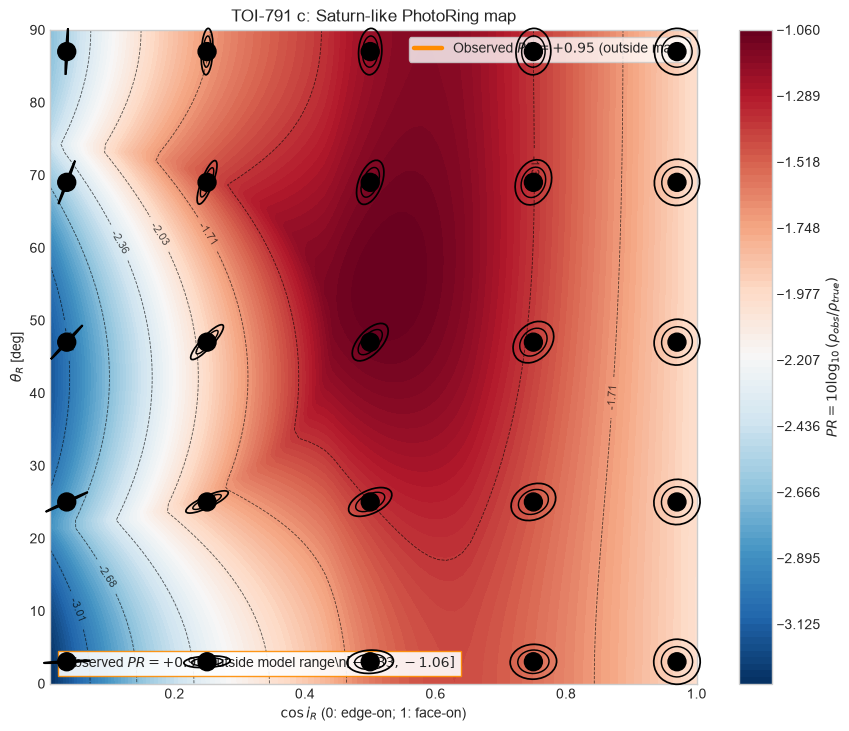

TOI-791 c: observed PR = +0.947; model range = [-3.331, -1.060]


{'TOI-791 b': PosixPath('/Users/jzuluaga/dev/PRisma/papers/TOI-791/figures/PRContour-TOI-791b.png'),
 'TOI-791 c': PosixPath('/Users/jzuluaga/dev/PRisma/papers/TOI-791/figures/PRContour-TOI-791c.png')}

In [21]:
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, DrawingArea
from matplotlib.patches import Circle, Ellipse

pipeline_dir = ROOT / 'pipeline'
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))
from exorings.forward import forward_observables

FI, FE, ALPHA = 1.526, 2.269, np.exp(-1)
cos_i_grid = np.linspace(0.01, 1.0, 81)
theta_grid = np.linspace(0.0, 90.0, 81)


def add_ring_glyph(ax, x, y, cos_i, theta_deg, size=38):
    canvas = DrawingArea(size, size, clip=False)
    center = size / 2
    outer = .88 * size
    inner = outer * FI / FE
    flattening = max(float(cos_i), .025)
    for diameter, width in [(outer, 1.25), (inner, 1.05)]:
        canvas.add_artist(Ellipse((center, center), diameter, diameter * flattening, angle=theta_deg, fill=False, edgecolor='black', linewidth=width))
    canvas.add_artist(Circle((center, center), .17 * size, color='black', zorder=5))
    ax.add_artist(AnnotationBbox(canvas, (x, y), frameon=False, pad=0, zorder=10))


def make_ring_map(planet, row):
    required = ['rho_true_kg_m3', 'rho_observed_over_true', 'period_day', 'p', 'b']
    if not all(np.isfinite(row[name]) for name in required):
        print(f'{planet}: skipped PhotoRing map; missing required catalog geometry.')
        return None
    ci_mesh, theta_mesh = np.meshgrid(cos_i_grid, theta_grid)
    pr_map = np.full_like(ci_mesh, np.nan, dtype=float)
    for j, cos_i in enumerate(cos_i_grid):
        ir_deg = np.degrees(np.arccos(cos_i))
        for i, theta_deg in enumerate(theta_grid):
            result = forward_observables(row['rho_true_kg_m3'] / 1000, row['period_day'], row['b'], row['p'], FI, FE, ALPHA, theta_deg, ir_deg)
            if result is not None:
                pr_map[i, j] = 10 * result['logPR']
    if not np.isfinite(pr_map).any():
        print(f'{planet}: no physical ring configurations in the grid.')
        return None

    zmin, zmax = np.nanmin(pr_map), np.nanmax(pr_map)
    observed_pr = 10 * np.log10(row['rho_observed_over_true'])
    fig, ax = plt.subplots(figsize=(8.4, 7.2), constrained_layout=True)
    levels = np.linspace(zmin, zmax, 100)
    field = ax.contourf(ci_mesh, theta_mesh, pr_map, levels=levels, cmap='RdBu_r')
    contours = ax.contour(ci_mesh, theta_mesh, pr_map, levels=np.linspace(zmin, zmax, 8), colors='black', linewidths=.6, alpha=.65)
    ax.clabel(contours, fmt='%.2f', fontsize=8)

    handles = []
    if zmin <= observed_pr <= zmax:
        observed_contour = ax.contour(ci_mesh, theta_mesh, pr_map, levels=[observed_pr], colors='darkorange', linewidths=3.2, zorder=8)
        observed_labels = ax.clabel(observed_contour, fmt={observed_pr: rf'$PR_{{\rm obs}}={observed_pr:+.2f}$'}, fontsize=9, inline=True)
        for label in observed_labels:
            label.set_fontweight('bold')
            label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=.8, pad=.15))
        handles.append(Line2D([], [], color='darkorange', lw=3.2, label=rf'Observed $PR={observed_pr:+.2f}$'))
    else:
        ax.text(.02, .02, rf'Observed $PR={observed_pr:+.2f}$ outside model range\n$[{zmin:+.2f}, {zmax:+.2f}]$', transform=ax.transAxes, va='bottom', ha='left', bbox=dict(facecolor='white', edgecolor='darkorange', alpha=.9))
        handles.append(Line2D([], [], color='darkorange', lw=3.2, label=rf'Observed $PR={observed_pr:+.2f}$ (outside map)'))

    for glyph_cos_i in [.035, .25, .50, .75, .97]:
        for glyph_theta in [3, 25, 47, 69, 87]:
            add_ring_glyph(ax, glyph_cos_i, glyph_theta, glyph_cos_i, glyph_theta)
    fig.colorbar(field, ax=ax, label=r'$PR=10\log_{10}(\rho_{obs}/\rho_{true})$')
    ax.set(xlim=(.01, 1), ylim=(0, 90), xlabel=r'$\cos i_R$ (0: edge-on; 1: face-on)', ylabel=r'$\theta_R$ [deg]', title=f'{planet}: Saturn-like PhotoRing map')
    ax.legend(handles=handles, loc='upper right', frameon=True)
    path = FIGURES / f'PRContour-{planet.replace(" ", "")}.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    pd.DataFrame(pr_map, index=theta_grid, columns=cos_i_grid).to_csv(DATA / f'photo_ring_map_{planet.replace(" ", "_")}.csv')
    print(f'{planet}: observed PR = {observed_pr:+.3f}; model range = [{zmin:+.3f}, {zmax:+.3f}]')
    return path


ring_paths = {planet: make_ring_map(planet, row) for planet, row in diagnostics.iterrows()}
ring_paths

## 5. Interpretation and next test

Compare b and c using the same host-star density, and treat agreement between planets as a consistency check rather than independent confirmation: stellar uncertainties and catalog systematics are shared. If either planet has a substantial circular-density anomaly, the decisive next analysis is a joint fit of the available transit light curves without a stellar-density prior, retaining posterior covariances and then combining with an independent stellar and RV/TTV analysis.

The generated CSV files preserve the numerical inputs and outputs under `data/toi791/`; figures are written under `figures/`. The raw NASA, Gaia, TIC, and MAST products should be inspected before using any result in a paper.